# Paracetamol: torsional states, their pruning by symmetry, and a summary

1. **Clustering** -- `t_hdbscan` partitions the torsional ensemble into density basins.
2. **Pruning** -- `t_symmetry` asks which of those basins are the SAME conformer seen through a
   permutation of chemically identical atoms, and merges only those.
3. **Summary** -- what survived: populations, per-torsion statistics, and a representative
   structure for each surviving group.

**A cluster is a density basin, not a metastable state.** Nothing here looks at time. Two peaks
separated by a sampled region are two clusters whatever the barrier between them.

**Needs the analysis environment** (`scikit-learn`, `rdkit`): see
[Installing](https://csy0000.github.io/MD-tools/install/#5-optional-the-analysis-environment).

> **ARCHIVED -- the historical cluster-then-merge workflow (md-tools 0.6.4).**
>
> This page is kept as a record. It clusters with the plain cos/sin Euclidean torsion distance,
> assigns frames with the historical 15-neighbour vote **margin**, and only then merges clusters
> related by molecular symmetry (`TorsionSymmetry`).
>
> **Source revision:** `docs/tutorial/paracetamol/analysis/clustering.ipynb` at commit
> `8516c12a` (tag `v0.6.4`). The outputs below are exactly the ones saved in that file; the
> notebook was **not re-executed** for this archive. Two things were updated for this location:
> the helper import path, and the install link, now an absolute site URL (as written it had never
> resolved on the site). No code that computes anything changed.
>
> **It does not run against the current package.** `t_hdbscan(angles)` now refuses an angles-only
> call because it clusters symmetry-first by default. To re-run this page, check out `v0.6.4`,
> or reproduce its numbers on the current package with
> `t_hdbscan(tors, symmetry=False, vote_rule="legacy-margin")` -- the comparison notebook does
> exactly that.
>
> **The current workflow** enumerates the symmetry *before* clustering:
> [Paracetamol: symmetry-first clustering](https://csy0000.github.io/MD-tools/tutorial/paracetamol/analysis/clustering/).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parents[2] / "_analysis"))   # docs/tutorial/_analysis

import numpy as np
import matplotlib.pyplot as plt
import mdtraj as md
import tutorial_data as td

# Where the runs are. NOT defaulted: see docs/tutorial/_analysis/tutorial_data.py.
# The resolved path is deliberately NOT printed. These notebooks are committed WITH
# their outputs, so an echoed absolute path would put one machine's layout into a
# published file -- which this project forbids, and which executing a notebook turns
# from a parameter into a stored string.
print("tutorial runs:", "found" if td.runs_root().is_dir() else "MISSING")

tutorial runs: found


In [2]:
PARA_TORSIONS = {"omega": (0, 1, 3, 4), "aryl": (1, 3, 4, 5), "phenol": (6, 7, 8, 17)}
names, quads = list(PARA_TORSIONS), list(PARA_TORSIONS.values())

## 1. Clustering

In [3]:
from md_tools.analysis import t_hdbscan

cmd = td.solute("PARA-1us", stride=25)          # 4000 frames is plenty for three torsions
tors = md.compute_dihedrals(cmd, quads)
print(f"{tors.shape[0]} frames, {tors.shape[1]} torsions")

fit = t_hdbscan(tors, names=names).fit()
summary = fit.summary()
print(f"n_clusters = {summary['n_clusters']}")
print(f"masses     = { {k: round(v, 3) for k, v in summary['cluster_mass'].items()} }")
print(f"noise      = {summary['noise_mass']:.4f}")

4000 frames, 3 torsions


n_clusters = 4
masses     = {0: 0.281, 1: 0.274, 2: 0.233, 3: 0.21}
noise      = 0.0022


### Is one state a possible answer here?

`allow_single_cluster` defaults to **True** in md-tools, which is a deliberate departure from
sklearn's default. With it False, HDBSCAN's EOM selection refuses the root of the condensed tree,
so a UNIMODAL ensemble cannot come back as one state -- it is split into two or three with a
plausible mass split and nothing in the output saying one state was never a candidate.

Paracetamol is a small, rigid molecule, so it is exactly the kind of system where that would have
bitten. Check it both ways rather than trusting either default.

In [4]:
for flag in (True, False):
    s = t_hdbscan(tors, names=names, allow_single_cluster=flag).fit().summary()
    print(f"allow_single_cluster={flag!s:5s} -> {s['n_clusters']} clusters, "
          f"excluded_by_construction={s['single_cluster_excluded_by_construction']}")
for caveat in summary["caveats"]:
    print("-", caveat)

allow_single_cluster=True  -> 4 clusters, excluded_by_construction=False


allow_single_cluster=False -> 4 clusters, excluded_by_construction=True
- cluster labels are ordered by descending population; HDBSCAN's own numbering is arbitrary and unrelated between fits
- draw_agreement is PRECISION, not accuracy: it says the count is stable under resampling, not that a small state was seen. Check that settings.min_cluster_size >= settings.min_samples first
- min_vote is a BOUNDARY detector, not a density test: against a direct fit's own noise it recalls about 7 %
- a cluster is a density basin, NOT a metastable state; nothing here looks at time
- two kinds of unassigned, and they are different claims: -2 is DENSITY noise (the neighbourhood is thinner than any clustered frame's -- nowhere in particular) and -1 is a BARRIER frame (the neighbours disagree about which cluster -- between two somewheres). Measured on a two-basin fixture they overlap only partly: a frame can be sparse yet unanimous, or dense yet split. Density takes precedence where both apply.
- a quer

The answer is the same either way here, so the structure is real rather than an artefact of the
default. Had it differed, the number to believe would be the one from `True` -- and the marginals
in the PMF notebook would settle it.


## 2. Pruning by symmetry

The four clusters are two torsions each taking two values. But the phenyl ring has a two-fold
axis: flipping it exchanges chemically identical atoms and changes no physics. `t_symmetry` finds
that operation from the molecular GRAPH -- not from the populations, not from the histograms --
and tests whether it maps one cluster's JOINT distribution onto another's.

In [5]:
from rdkit import Chem
from md_tools.analysis import load_torsion_json, load_cluster_torsion, TorsionSymmetry
import json, tempfile, os

mol = Chem.SDMolSupplier(str(td.run_dir("PARA-REST2") / "build/TYL.sdf"), removeHs=False)[0]

# The SDF's atom order and the trajectory's are NOT assumed equal -- verified by bond graph.
from md_tools.analysis import verify_atom_mapping
bonds = [(b[0].index, b[1].index) for b in cmd.topology.bonds]
elements = [a.element.symbol for a in cmd.topology.atoms]
mapping, why = verify_atom_mapping(mol, bonds, elements)
print("atom mapping:", "identity" if mapping == list(range(mol.GetNumAtoms())) else mapping)
print(" ", why)

atom mapping: identity
  identity verified: elements and the full bond graph agree under this mapping


In [6]:
definition = {"schema_version": 1, "indexing": "zero-based", "units": "radian",
              "torsions": [{"name": n, "atoms": list(q)} for n, q in PARA_TORSIONS.items()]}
path = pathlib.Path(tempfile.mkdtemp()) / "torsion_cv.json"
path.write_text(json.dumps(definition, indent=2))

torsion_idx = load_torsion_json(path, molecule=mol)
clusters = load_cluster_torsion(tors, fit.labels_, noise_label=-1, angle_unit="radian",
                                names=list(torsion_idx.names))
print("cluster labels:", clusters.cluster_labels, "| masses:", clusters.mass_table())

cluster labels: [0, 1, 2, 3] | masses: {'clusters': {0: 0.281, 1: 0.274, 2: 0.233, 3: 0.20975}, 'noise': 0.0, 'unassigned': {-2: 0.00225}, 'sum': 1.0}


In [7]:
detector = TorsionSymmetry(mol, torsion_idx)
detector.fit(clusters, coordinates=cmd.xyz, atom_mapping=mapping)

print("operations distinct on these torsions:", len(detector.operations))
print("groups:", detector.cluster_groups)
for c in detector.comparisons:
    if c.evidence.get("role") == "transitivity-guard":
        continue
    print(f"  {c.a} vs {c.b}: {c.verdict:9s} op={c.operation} "
          f"E={c.energy if c.energy is None else round(c.energy, 4)}")

operations distinct on these torsions: 2
groups: [[0, 2], [1, 3]]
  0 vs 1: rejected  op=1 E=2.4346
  0 vs 2: accepted  op=1 E=-0.0008
  0 vs 3: rejected  op=1 E=2.566
  1 vs 2: rejected  op=1 E=2.5693
  1 vs 3: accepted  op=1 E=-0.0001
  2 vs 3: rejected  op=1 E=2.4356
  0 vs 2: accepted  op=1 E=-0.0008
  1 vs 3: accepted  op=1 E=-0.0001


**Not all four merge.** The ring flip relates 0 to 2 and 1 to 3, but nothing relates those two
groups: one is the pairing where both torsions sit together, the other where they are opposite,
and those are genuinely different relative orientations. The tolerance is calibrated from the
within-cluster split-half variability of THESE data, not from a universal constant.

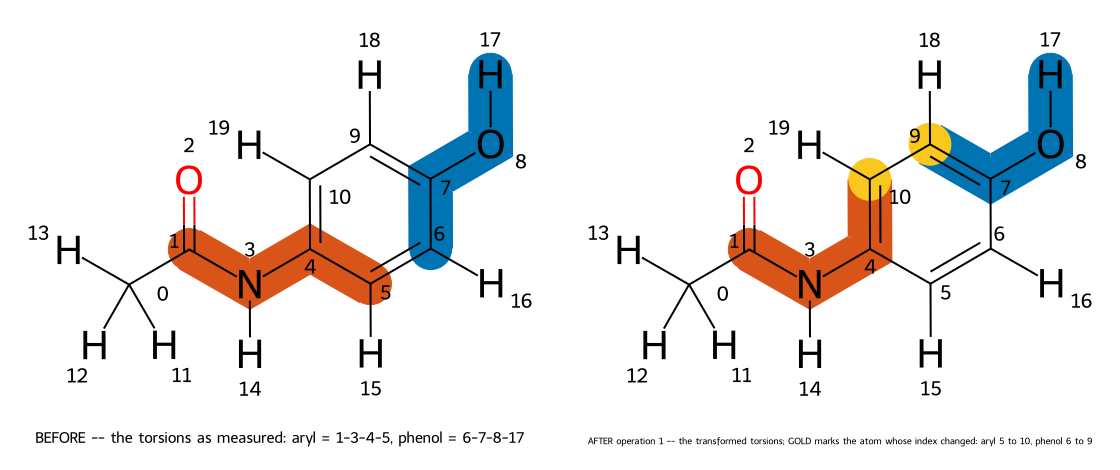

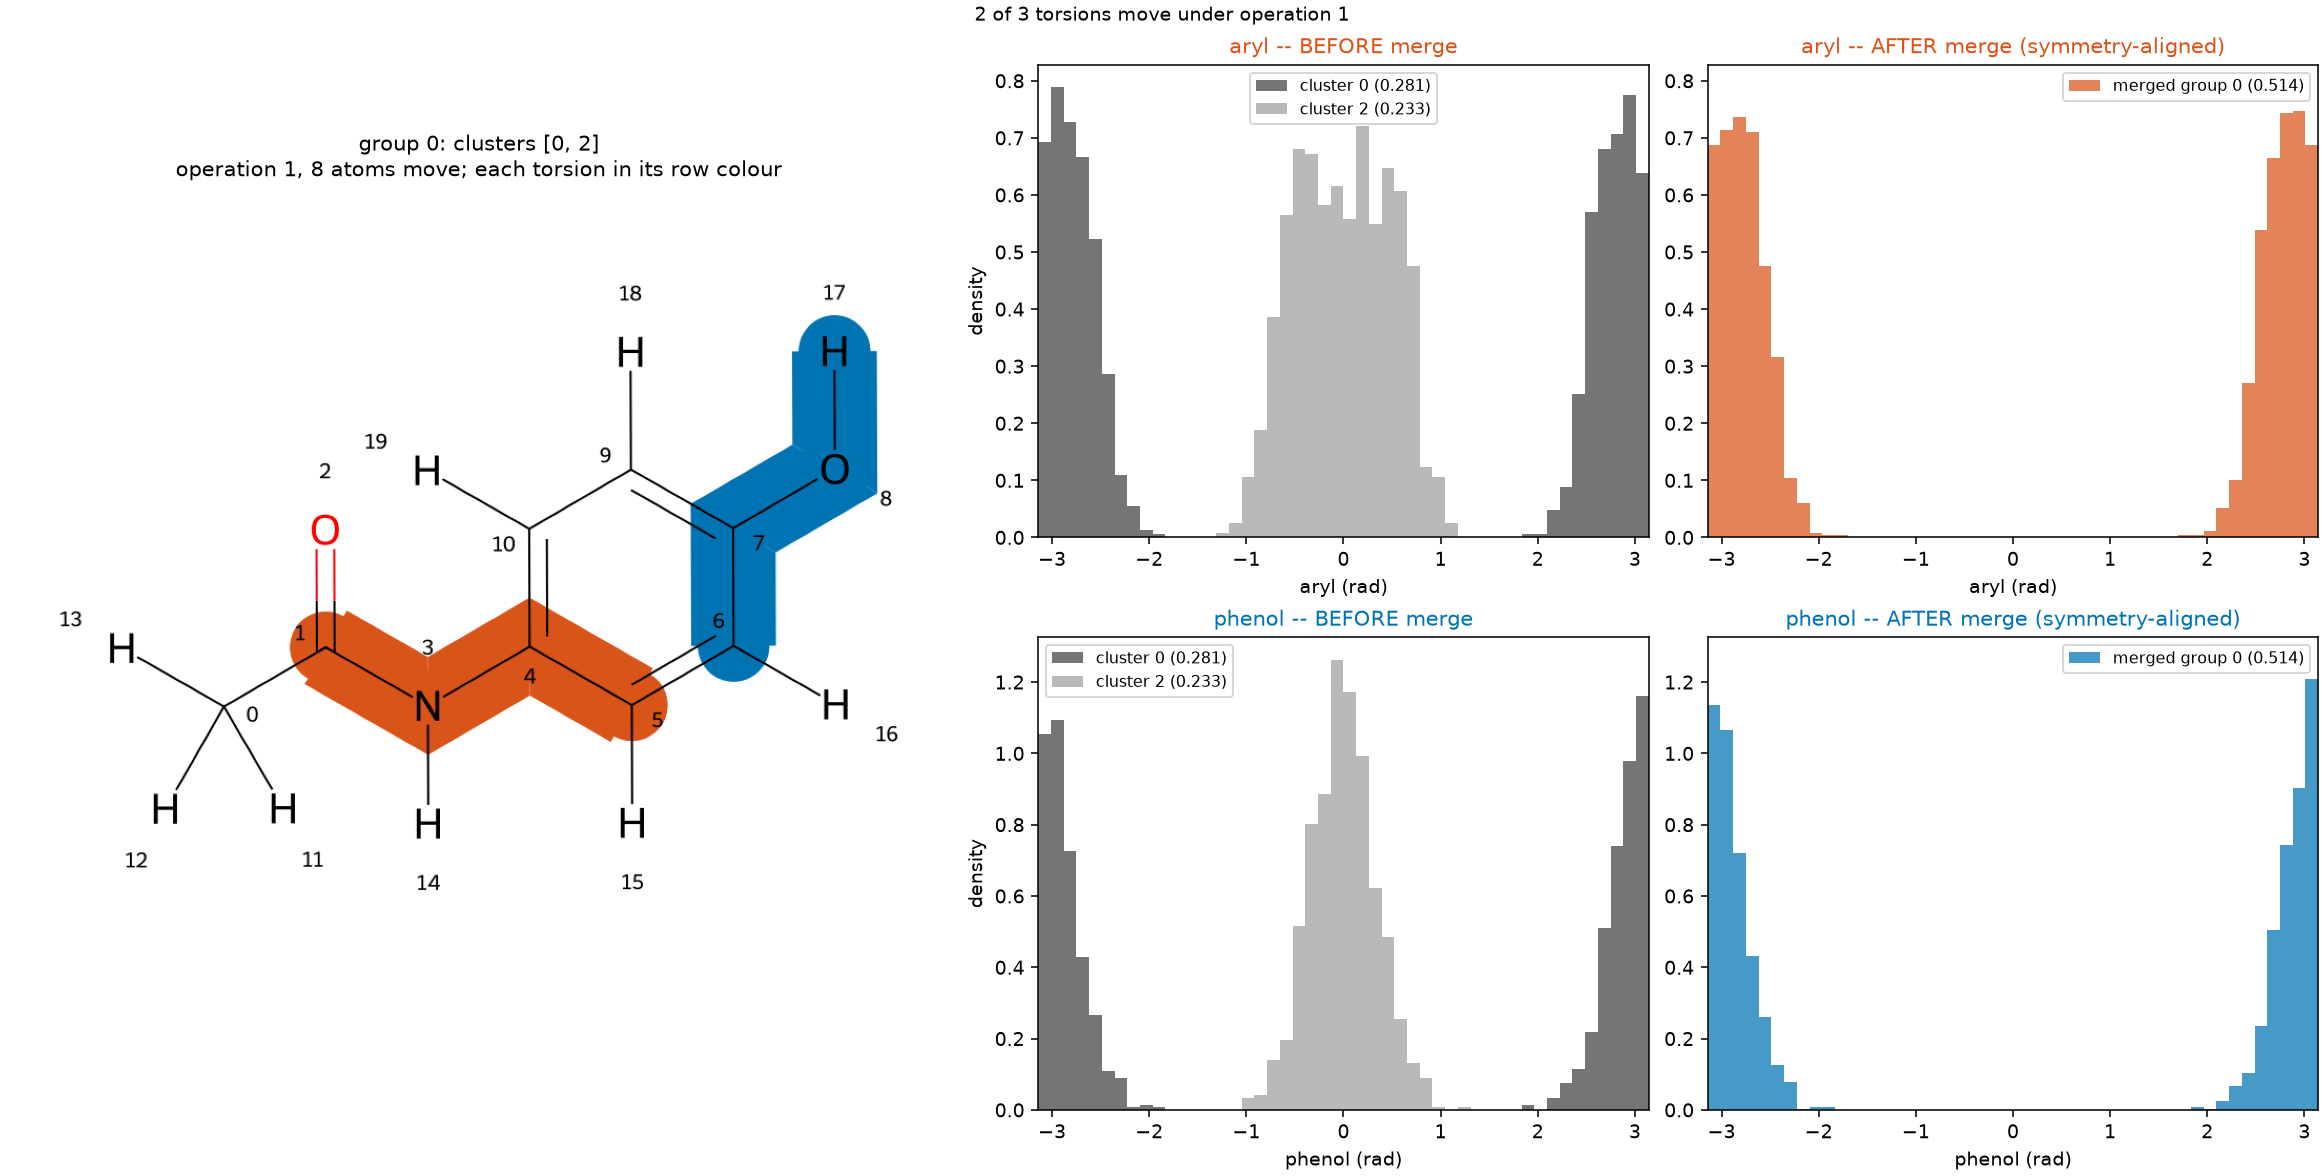

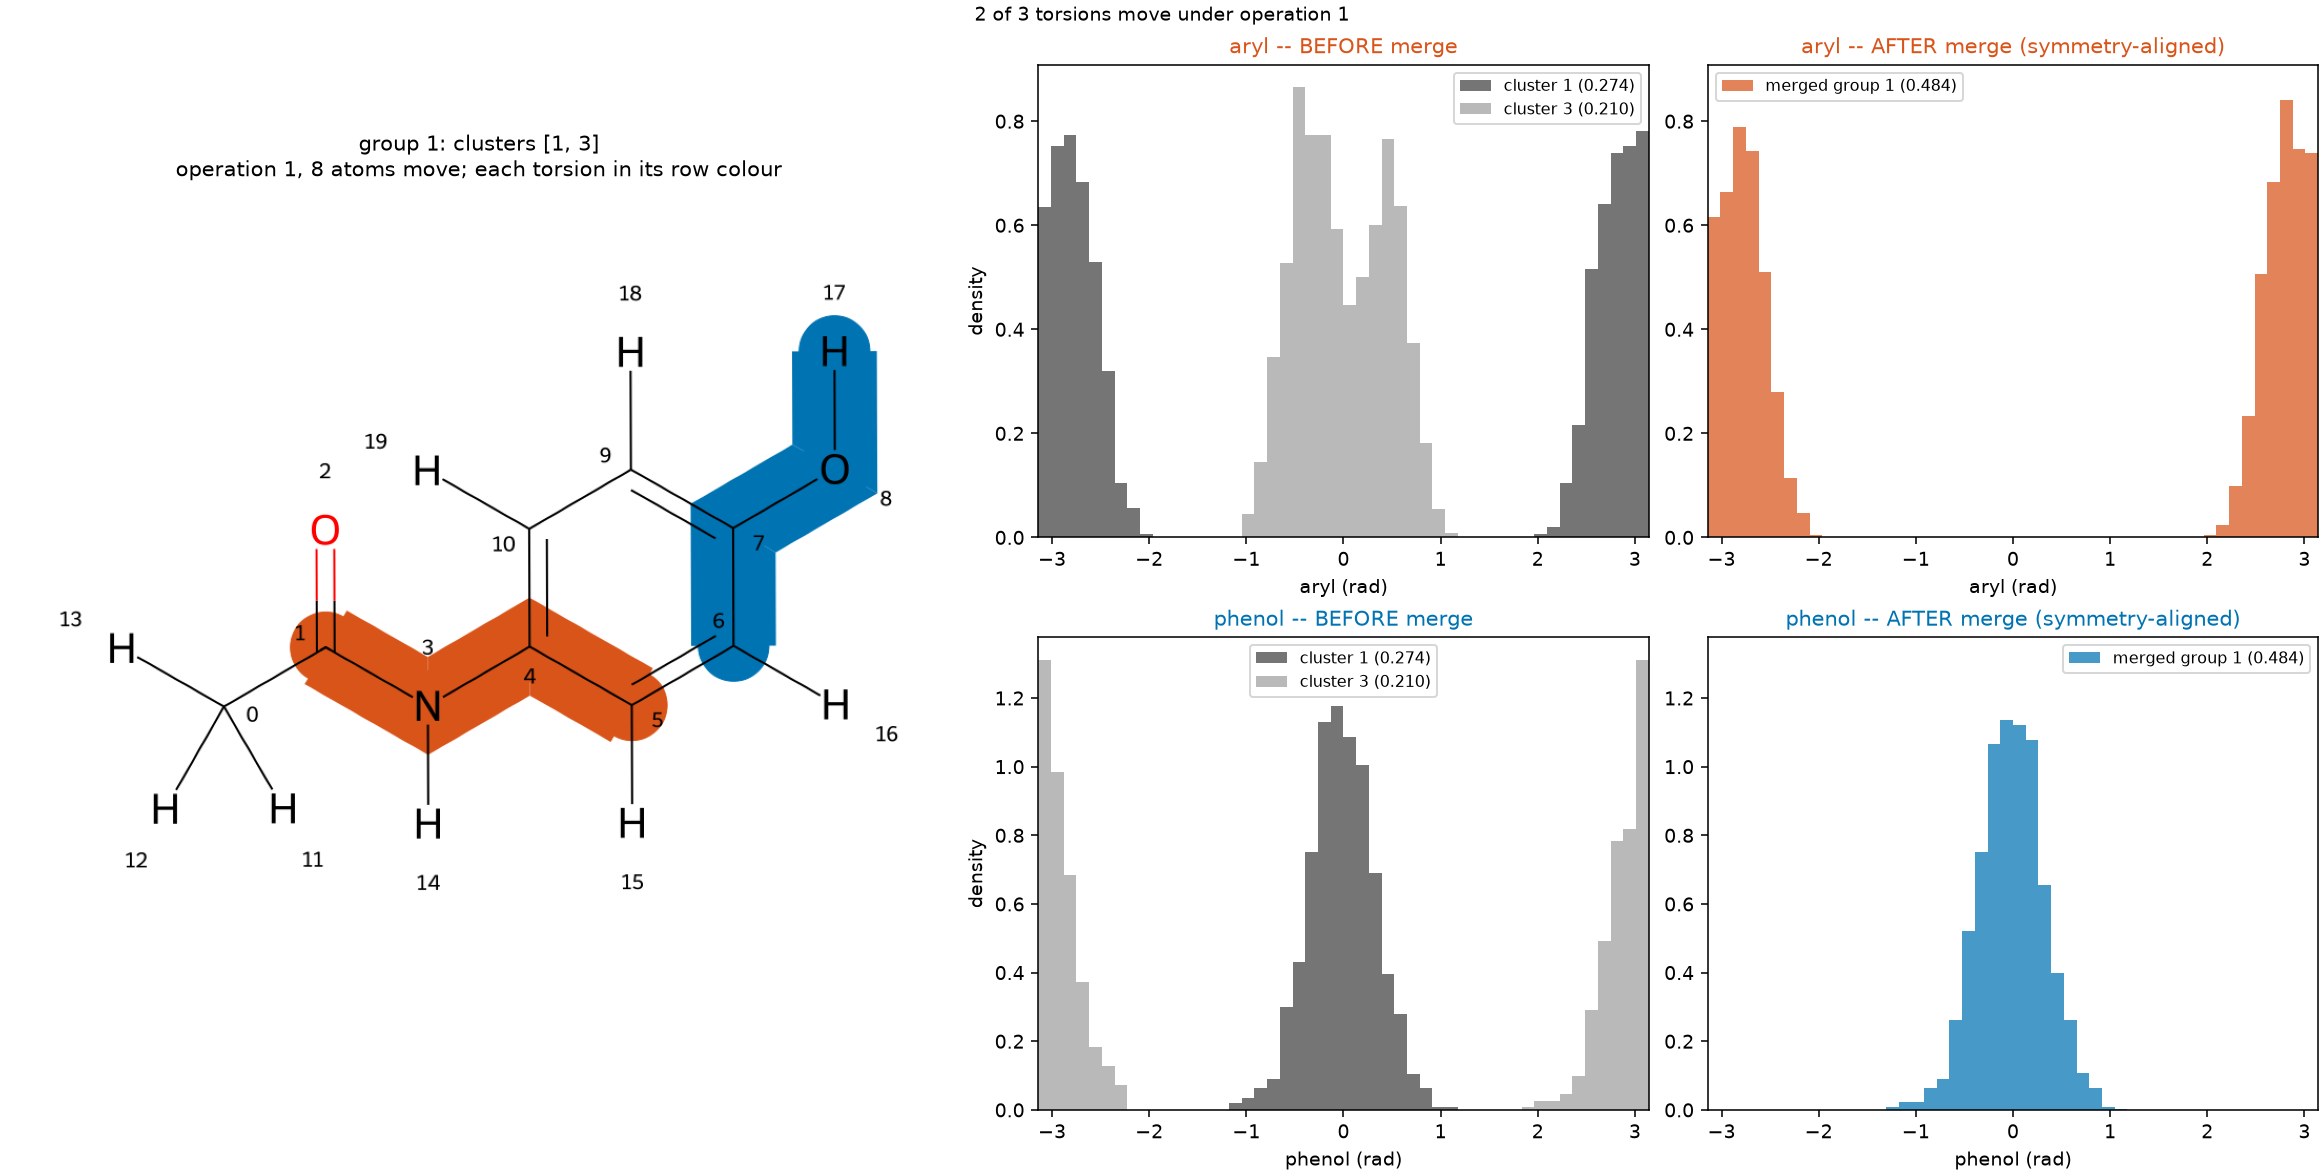

In [8]:
detector.draw_operation_effect(group=0, output="operation.png")
detector.draw_sym_group(0, output="group_0.png", cluster_torsions=clusters)
detector.draw_sym_group(1, output="group_1.png", cluster_torsions=clusters)

from IPython.display import Image, display
for name in ("operation.png", "group_0.png", "group_1.png"):
    display(Image(filename=name))

In [9]:
merged = detector.deduplicate(clusters)
print(json.dumps(merged.describe(), indent=2))
assert abs(sum(merged.masses.values()) + merged.noise_mass - 1.0) < 1e-9
print("\npopulations are conserved: merged masses + noise == 1 exactly")

{
  "groups": [
    [
      0,
      2
    ],
    [
      1,
      3
    ]
  ],
  "original_to_merged": {
    "0": 0,
    "1": 1,
    "2": 0,
    "3": 1
  },
  "masses": {
    "0": 0.514,
    "1": 0.48375
  },
  "noise_mass": 0.00225,
  "operations_used": {
    "0": null,
    "1": null,
    "2": 1,
    "3": 1
  },
  "mass_sum_including_noise": 1.0
}

populations are conserved: merged masses + noise == 1 exactly


## 3. Summary

What survived the pruning. A merged group is no longer "cluster 2" -- it is a SET of original
labels -- so it gets a LETTER. Reusing an integer for both invites them to be confused in the one
place the difference matters.

In [10]:
import pandas as pd
from md_tools.analysis import (group_name, representative_by_vote,
                               strip_nonpolar_hydrogens, draw_representative_structures)

reps = representative_by_vote(fit)
groups = {group_name(i): g for i, g in enumerate(detector.cluster_groups)}
chosen = {name: reps[members[0]] for name, members in groups.items()}

# The SYMMETRY-ALIGNED angles, which is what a merged group's distribution means: every member
# mapped through the operation that relates it to the group's reference.
aligned = {name: merged.aligned[i] for i, name in enumerate(groups)}
for name, members in groups.items():
    print(f"group {name}: clusters {members}  mass {merged.masses[list(groups).index(name)]:.4f}"
          f"  representative frame {chosen[name]}")

group A: clusters [0, 2]  mass 0.5140  representative frame 1
group B: clusters [1, 3]  mass 0.4838  representative frame 0


### Each group's torsion distributions

One panel per torsion, one colour per GROUP, `histtype="step"` so the outlines do not hide each
other -- a filled histogram of two overlapping groups shows whichever was drawn last.

Text(0.5, 0.98, 'Symmetry-aligned torsion distributions, one colour per merged group')

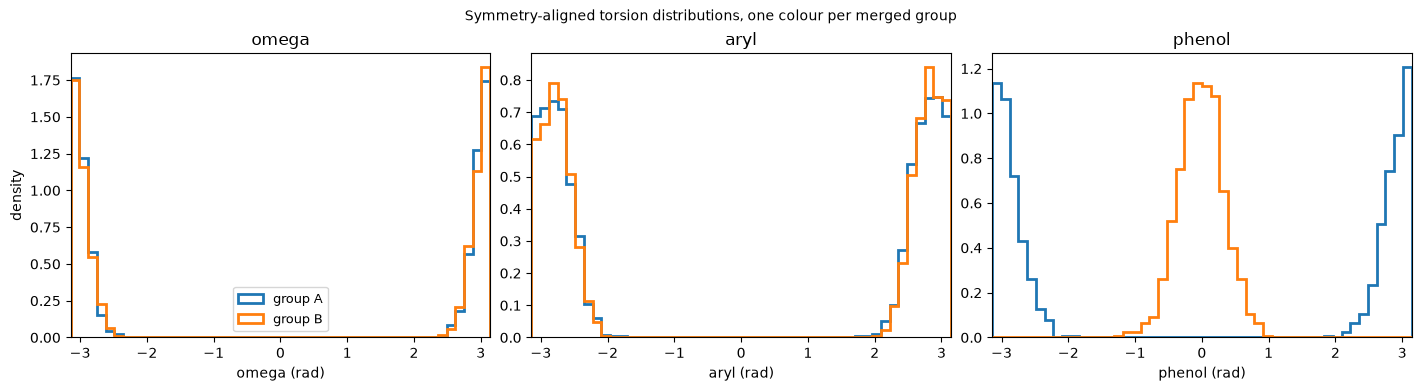

In [11]:
fig, axes = plt.subplots(1, len(names), figsize=(4.7 * len(names), 3.8), layout="constrained")
edges = np.linspace(-np.pi, np.pi, 49)
palette = plt.get_cmap("tab10")

for column, (axis, torsion) in enumerate(zip(np.atleast_1d(axes), names)):
    for k, (name, values) in enumerate(aligned.items()):
        axis.hist(values[:, column], bins=edges, density=True, histtype="step",
                  lw=2.0, color=palette(k), label=f"group {name}")
    axis.set_xlim(-np.pi, np.pi)
    axis.set_xlabel(f"{torsion} (rad)")
    axis.set_title(torsion)
    if column == 0:
        axis.set_ylabel("density"); axis.legend(fontsize=9)
fig.suptitle("Symmetry-aligned torsion distributions, one colour per merged group", fontsize=10)

### The table

Circular statistics, not arithmetic ones. The mean of +179 and -179 degrees is NOT 0: on a circle
those two are neighbours, and averaging them linearly puts the answer on the opposite side. So
`t1_avg` is the mean DIRECTION and `t1_std` the circular standard deviation
`sqrt(-2 ln R)`, where `R` is the resultant length -- which goes to zero for a tight
distribution and grows without bound as one spreads over the whole circle.

In [12]:
def circular_mean(values):
    return float(np.arctan2(np.sin(values).mean(), np.cos(values).mean()))

def circular_std(values):
    resultant = np.hypot(np.sin(values).mean(), np.cos(values).mean())
    return float(np.sqrt(-2.0 * np.log(max(resultant, 1e-12))))

rows = []
for i, (name, members) in enumerate(groups.items()):
    values = aligned[name]
    row = {"cluster_id": name, "original_clusters": ",".join(str(m) for m in members)}
    for column, torsion in enumerate(names):
        row[f"{torsion}_avg"] = np.rad2deg(circular_mean(values[:, column]))
        row[f"{torsion}_std"] = np.rad2deg(circular_std(values[:, column]))
    row["n_samples"] = int(values.shape[0])
    row["mass"] = float(merged.masses[i])
    rows.append(row)

df = pd.DataFrame(rows).round(3)
df.head()

,cluster_id,original_clusters,omega_avg,omega_std,aryl_avg,aryl_std,phenol_avg,phenol_std,n_samples,mass
0,A,"0,2",179.872,12.314,-179.833,25.174,-179.948,19.562,2056,0.514
1,B,"1,3",179.962,12.655,-179.513,24.467,-0.822,19.346,1935,0.484


`mass` is the weighted fraction of the WHOLE ensemble, noise included, so the masses plus the
noise mass come to exactly 1. Nothing is multiplied by the symmetry order: the order says how
many labels the ensemble was split into, not how much probability it holds.

### A representative structure per group

An ACTUAL FRAME, never an average: the mean of two Cartesian structures is not a structure, and
the circular mean of a bimodal torsion points at the barrier between its basins -- the one place
the molecule is never found. The frame chosen is the one with the highest k-NN VOTE MARGIN, the
configuration its neighbours agree about most strongly and so the furthest from any boundary.
Ties are the common case on a well-separated partition, since most frames are unanimous, and the
FIRST is taken deterministically so the figure does not move between runs.

Superposed, so what differs between panels is CONFORMATION rather than where the box left the
molecule. Nonpolar hydrogens removed; **polar H kept**, because an O-H orientation is part of the
conformation -- and here it is literally the `phenol` torsion that separates the groups.

13 atoms drawn, superposed: True


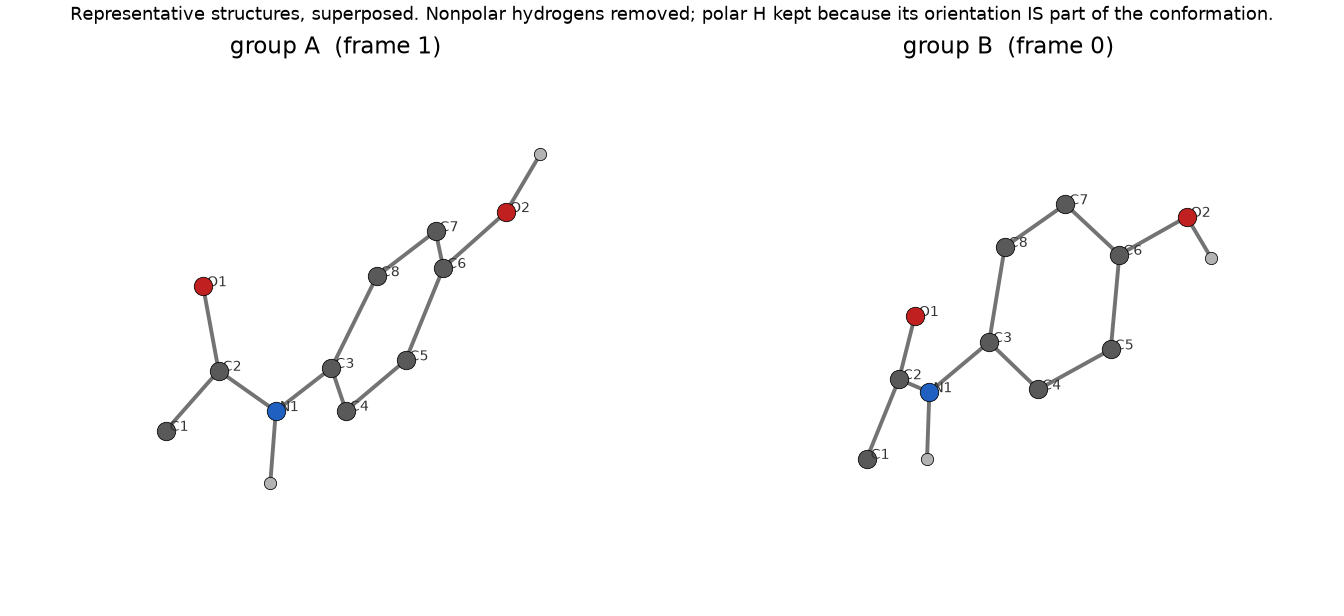

In [13]:
# Nonpolar hydrogens removed; POLAR H kept, because an O-H or N-H orientation is part of the
# conformation being shown -- and here it is literally the `phenol` torsion.
keep = strip_nonpolar_hydrogens(cmd)
info = draw_representative_structures(cmd, chosen, output="representatives.png",
                                      atom_indices=keep)
print(f"{info['n_atoms_drawn']} atoms drawn, superposed: {info['aligned']}")
display(Image(filename="representatives.png"))

**Want it interactive?** `nglview` gives a rotatable viewer in a live notebook:

```python
import nglview, mdtraj as md
view = nglview.show_mdtraj(cmd.atom_slice(keep)[[chosen["A"], chosen["B"]]])
view
```

It is not used for the figure above because a widget renders as NOTHING when this notebook is
read on GitHub, and these notebooks are committed with their outputs precisely so they can be
read without being run. `draw_representative_structures` returns the aligned coordinates
(`info["aligned_xyz_nm"]`) for any viewer you prefer.

Masses SUM across a merge; nothing is multiplied by the symmetry order. The group's order says
how many labels the ensemble was split into, not how much probability it holds -- and the noise
label keeps its own mass rather than being absorbed.

**A structural claim is not a thermodynamic one.** That two clusters are related by a graph
automorphism says their conformations are equivalent. If an atom-specific restraint or a REST2
region covers one side and not the other, the symmetry is broken even though the graph is
unchanged -- pass `broken_by=[...]` to record that, and it travels with every accepted pair.